# CSoT'26 — ML in Astronomy — Week 1 · Part 2: Data Pipeline (Starter)

**Goal:** Get the Galaxy Zoo 2 images flowing through a PyTorch data pipeline and *look at them*.

By the end you'll join the official morphology labels to flat image files, build an `ImageFolder`-ready layout, create a `DataLoader` yielding `(32, 3, 64, 64)` batches, and plot a matplotlib grid of real galaxies.

**Before you begin:**
1. Finish **Part 1** (`week1_starter.ipynb`) first.
2. Switch this notebook to a **GPU runtime** (`Runtime → Change runtime type → GPU`). Not strictly required for data loading, but keeps you consistent.
3. Read [`08-data-pipelines.md`](../08-data-pipelines.md) — every TODO below maps to a section there.

> **Heads-up:** The [Kaggle Galaxy Zoo 2 download](https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images) does **not** ship class subfolders. Images are named `{asset_id}.jpg` in a flat folder; labels live in CSV catalogues. We join them first, then use `ImageFolder`.

Attempt every TODO before opening `week1_data_solution.ipynb`.

## Step 0 — Imports

In [1]:
import os
import random
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## Step 1 — Get the dataset into Colab

The Kaggle bundle contains:
- `images_gz2.zip` — ~243k JPGs named `1.jpg`, `2.jpg`, … (no class folders)
- `gz2_filename_mapping.csv` — maps each `asset_id` to an SDSS `objid`

Morphology labels come separately from the official GZ2 catalogue ([Hart et al. 2016](https://data.galaxyzoo.org/)), which we download as `gz2_hart16.csv.gz`.

**Option A — Kaggle API (recommended).** Upload your `kaggle.json` token, then run the download/unzip commands in the solution notebook (or adapt the cell below).

Fill in the cell below to download/locate the data and set the paths.

In [6]:
# TODO: download + unzip the Kaggle dataset and Hart et al. labels.
#       Set RAW_ROOT (raw download), IMAGES_DIR (flat JPG folder), and DATA_ROOT (organized for ImageFolder).
#
# Expected after setup:
#   RAW_ROOT/gz2_filename_mapping.csv
#   IMAGES_DIR/123.jpg, IMAGES_DIR/124.jpg, ...
#   RAW_ROOT/gz2_hart16.csv
#   DATA_ROOT/elliptical/*.jpg  (you create this in Step 3)
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
# Download Galaxy Zoo 2 images dataset
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
# Create raw data folder
!mkdir -p galaxy_raw
# Unzip dataset
!unzip -q galaxy-zoo-2-images.zip -d galaxy_raw
# Download Hart et al. labels
!wget -q -O galaxy_raw/gz2_hart16.csv.gz \
https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
# Unzip labels csv
!gunzip -f galaxy_raw/gz2_hart16.csv.gz
# Paths used later
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2/images"
DATA_ROOT = Path("galaxy_data")
print("RAW_ROOT =", RAW_ROOT)
print("IMAGES_DIR =", IMAGES_DIR)
print("DATA_ROOT =", DATA_ROOT)


Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
galaxy-zoo-2-images.zip: Skipping, found more recently modified local copy (use --force to force download)
replace galaxy_raw/gz2_filename_mapping.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
RAW_ROOT = galaxy_raw
IMAGES_DIR = galaxy_raw/images_gz2/images
DATA_ROOT = galaxy_data


In [3]:
!find galaxy_raw -maxdepth 2
!kaggle datasets list -s "galaxy zoo"

galaxy_raw
galaxy_raw/gz2_hart16.csv
ref                                       title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jaimetrickz/galaxy-zoo-2-images           Galaxy Zoo 2: Images                           3281862708  2021-01-26 16:25:27.667000           8630         34  0.9411765        
robertmifsud/resized-reduced-gz2-images   Resized and Reduced Galaxy Zoo 2 Images        1934213890  2023-05-25 23:12:04.167000            694          6  0.8235294        
anjosut/galaxy-zoo-classification         Galaxy Zoo classification                       397550426  2023-04-08 04:28:53.070000            631          3  0.3529412        
zhuangjw/galaxy-zoo-cleaned               galaxy_zoo_cleaned                             235235341

## Step 2 — Inspect the raw layout

List what's inside `RAW_ROOT` and peek at `IMAGES_DIR`. You should see a CSV mapping file and many JPGs named by integer ID — **not** morphology subfolders.

Also open `gz2_filename_mapping.csv` and confirm columns `objid`, `sample`, `asset_id`.

In [7]:
# TODO: print os.listdir(RAW_ROOT) and count a few files in IMAGES_DIR.
#       Hint: Path(IMAGES_DIR).glob("*.jpg")
print("Contents of RAW_ROOT:")
print(os.listdir(RAW_ROOT))
print("\nNumber of jpg files:")
print(len(list(Path(IMAGES_DIR).glob("*.jpg"))))
print("\nFirst 10 jpg files:")
for p in list(Path(IMAGES_DIR).glob("*.jpg"))[:10]:
    print(p.name)
mapping = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv")
print("\nColumns:")
print(mapping.columns.tolist())
mapping.head()

Contents of RAW_ROOT:
['gz2_filename_mapping.csv', 'images_gz2', 'gz2_hart16.csv']

Number of jpg files:
243434

First 10 jpg files:
129893.jpg
269557.jpg
223555.jpg
92378.jpg
90024.jpg
22112.jpg
155435.jpg
131741.jpg
66448.jpg
156580.jpg

Columns:
['objid', 'sample', 'asset_id']


,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5


## Step 3 — Join labels and build an ImageFolder layout

`ImageFolder` expects `root/<class_name>/<image>.jpg`. Our Kaggle download doesn't provide that, so we:

1. Merge `gz2_filename_mapping.csv` with `gz2_hart16.csv` on `objid`.
2. Collapse the detailed `gz2_class` string (e.g. `Sc2t`, `Ei`) into a few high-level buckets.
3. Symlink a **balanced subset** into `DATA_ROOT/<class>/` so Colab stays fast.

Implement `high_level_label(gz2_class)` and `build_imagefolder_layout(...)` — see [`08-data-pipelines.md`](../08-data-pipelines.md).

In [9]:
mapping_df = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv")
labels_df = pd.read_csv(RAW_ROOT / "gz2_hart16.csv")

print("Mapping columns:")
print(mapping_df.columns.tolist())

print("\nLabels columns:")
print(labels_df.columns.tolist())

Mapping columns:
['objid', 'sample', 'asset_id']

Labels columns:
['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag', 't01_smooth_or_features_a02_features_or_disk_count', 't01_smooth_or_features_a02_features_or_disk_weight', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_debiased', 't01_smooth_or_features_a02_features_or_disk_flag', 't01_smooth_or_features_a03_star_or_artifact_count', 't01_smooth_or_features_a03_star_or_artifact_weight', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_

In [10]:
# TODO: define high_level_label(gz2_class) -> str | None
#       E* -> "elliptical", SB* -> "spiral_barred", S* -> "spiral"; skip "A" (artifact)
def high_level_label(gz2_class):
    if pd.isna(gz2_class):
        return None
    gz2_class = str(gz2_class)
    if gz2_class.startswith("A"):
        return None          # artifact
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    if gz2_class.startswith("E"):
        return "elliptical"
    return None

# TODO: define build_imagefolder_layout(...) that merges CSVs and symlinks
#       PER_CLASS images per class into DATA_ROOT/<label>/.
#       Call it once with PER_CLASS = 200 (or similar).
def build_imagefolder_layout(images_dir,
                             mapping_csv,
                             labels_csv,
                             output_root,
                             per_class=200):
    mapping_df = pd.read_csv(mapping_csv)
    labels_df = pd.read_csv(labels_csv)
    # merge using objid
    merged = mapping_df.merge(labels_df, left_on="objid", right_on="dr7objid")
    # convert detailed labels to coarse labels
    merged["label"] = merged["gz2_class"].apply(high_level_label)
    # remove unlabeled/artifact rows
    merged = merged.dropna(subset=["label"])
    output_root = Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)
    for label in merged["label"].unique():
        (output_root / label).mkdir(exist_ok=True)
    for label in merged["label"].unique():
        subset = merged[merged["label"] == label].head(per_class)
        for _, row in subset.iterrows():
            asset_id = row["asset_id"]
            src = Path(images_dir) / f"{asset_id}.jpg"
            if not src.exists():
                continue
            dst = output_root / label / f"{asset_id}.jpg"
            if not dst.exists():
                os.symlink(src.resolve(), dst)
    print("Finished creating ImageFolder layout.")

PER_CLASS = 200
build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS
)
# build_imagefolder_layout(IMAGES_DIR, RAW_ROOT / "gz2_filename_mapping.csv",
#                          RAW_ROOT / "gz2_hart16.csv", DATA_ROOT, per_class=PER_CLASS)

Finished creating ImageFolder layout.


## Step 4 — Build the transforms pipeline

Compose: `Resize((64, 64))` → `ToTensor()` → `Normalize([0.5]*3, [0.5]*3)`.
See [`08-data-pipelines.md`](../08-data-pipelines.md) for why each step exists and why order matters.

In [11]:
# TODO: transform = transforms.Compose([... Resize, ToTensor, Normalize ...])
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

## Step 5 — Wrap it in an ImageFolder

Create `dataset = ImageFolder(root=DATA_ROOT, transform=transform)`. Print `len(dataset)`, `dataset.classes`, and `dataset.class_to_idx`.

*Remember:* classes are assigned **alphabetically** — and only exist because we created the subfolders in Step 3.

In [12]:
# TODO: create the ImageFolder and print len / classes / class_to_idx.
dataset = ImageFolder(
    root=DATA_ROOT,
    transform=transform
)
print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)

Dataset size: 600
Classes: ['elliptical', 'spiral', 'spiral_barred']
Class mapping: {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}


## Step 6 — Fetch a single sample

In [13]:
# TODO: fetch dataset[0] and print its shape, dtype, and label.
sample = dataset[0]
print("Sample shape:", sample[0].shape)
print("Sample dtype:", sample[0].dtype)
print("Sample label:", sample[1])

Sample shape: torch.Size([3, 64, 64])
Sample dtype: torch.float32
Sample label: 0


## Step 7 — Build a DataLoader and peek at one batch

In [14]:
# TODO: build the DataLoader, grab one batch, and print the batch shapes.
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)
images, labels = next(iter(loader))
print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Labels dtype:", labels.dtype)

Images batch shape: torch.Size([32, 3, 64, 64])
Labels batch shape: torch.Size([32])
Labels dtype: torch.int64


## Step 8 — Plot a batch of galaxies

Plot ~16 images using `torchvision.utils.make_grid` + `plt.imshow`.

**Two gotchas:**
1. Undo the normalisation before plotting: `images * 0.5 + 0.5`.
2. matplotlib wants `(H, W, C)`, so `.permute(1, 2, 0)`.

Bonus: print the class names for the batch using `dataset.classes` and the `labels` tensor.

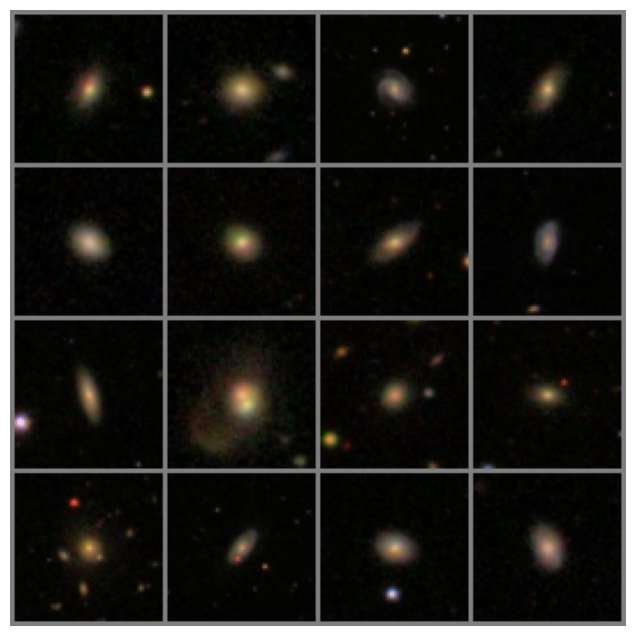

In [15]:
from torchvision.utils import make_grid
# TODO: un-normalise, make_grid(images[:16], nrow=4), permute, imshow, axis off.
images, labels = next(iter(loader))
grid = make_grid(images[:16], nrow=4)
# undo normalization
grid = grid * 0.5 + 0.5
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

## Stretch Goals *(optional)*

See [`09-project-task.md`](../09-project-task.md) for full descriptions:

1. Make a reproducible train/val split with `random_split` (seed it!).
2. Compute the **real** per-channel mean/std of the training set and use those in `Normalize`.
3. Plot several examples of each class side by side; guess which two will confuse a model.
4. Add `RandomHorizontalFlip` + `RandomRotation(180)` to a *train-only* transform and watch a galaxy flip/rotate.

In [ ]:
# TODO (optional): one or more stretch goals.

## Reflection *(write 2–3 sentences each)*

Answer the prompts from [`09-project-task.md`](../09-project-task.md):

1. Most confusing part of setup / the data pipeline, and how you resolved it.
2. Pick one galaxy class and describe what a CNN must detect to recognise it.
3. After viewing real batches: which two classes will be hardest to tell apart, and why?
4. Why so much effort on the data pipeline *before* any model?

*(Replace this prompt with your answers.)*